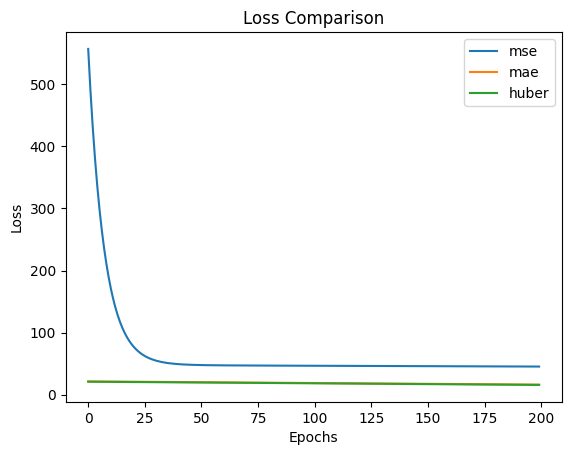

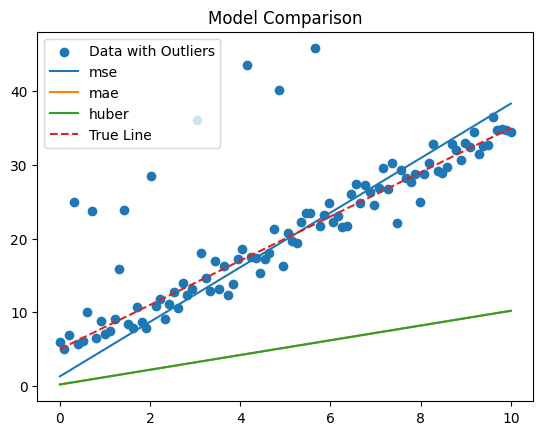

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# 1. Generate Data

np.random.seed(42)

X = np.linspace(0, 10, 100)
y_true = 3 * X + 5

# Clean noise
noise = np.random.normal(0, 2, size=X.shape)
y = y_true + noise

# Add outliers
y_outliers = y.copy()
outlier_indices = np.random.choice(len(X), size=10, replace=False)
y_outliers[outlier_indices] += np.random.normal(20, 5, size=10)


# 2. Loss Functions

def mse_loss(y, y_pred):
    return np.mean((y - y_pred)**2)

def mae_loss(y, y_pred):
    return np.mean(np.abs(y - y_pred))

def huber_loss(y, y_pred, delta=1.0):
    error = y - y_pred
    condition = np.abs(error) <= delta
    squared_loss = 0.5 * error**2
    linear_loss = delta * (np.abs(error) - 0.5 * delta)
    return np.mean(np.where(condition, squared_loss, linear_loss))


# 3. Gradient Descent Training

def train(X, y, loss_type='mse', lr=0.001, epochs=200):
    w, b = 0.0, 0.0
    losses = []

    for _ in range(epochs):
        y_pred = w * X + b
        error = y - y_pred

        # Gradients
        if loss_type == 'mse':
            dw = -2 * np.mean(X * error)
            db = -2 * np.mean(error)

        elif loss_type == 'mae':
            dw = -np.mean(X * np.sign(error))
            db = -np.mean(np.sign(error))

        elif loss_type == 'huber':
            delta = 1.0
            grad = np.where(np.abs(error) <= delta, error, delta * np.sign(error))
            dw = -np.mean(X * grad)
            db = -np.mean(grad)

        # Update
        w -= lr * dw
        b -= lr * db

        # Compute loss
        if loss_type == 'mse':
            loss = mse_loss(y, y_pred)
        elif loss_type == 'mae':
            loss = mae_loss(y, y_pred)
        else:
            loss = huber_loss(y, y_pred)

        losses.append(loss)

    return w, b, losses


# 4. Train Models

results = {}

for loss in ['mse', 'mae', 'huber']:
    w, b, losses = train(X, y_outliers, loss_type=loss)
    results[loss] = (w, b, losses)


# 5. Plot Loss Curves

plt.figure()
for loss in results:
    plt.plot(results[loss][2], label=loss)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.show()

# -----------------------------
# 6. Plot Predictions
# -----------------------------
plt.figure()
plt.scatter(X, y_outliers, label="Data with Outliers")

for loss in results:
    w, b, _ = results[loss]
    plt.plot(X, w * X + b, label=loss)

plt.plot(X, y_true, linestyle='dashed', label='True Line')

plt.legend()
plt.title("Model Comparison")
plt.show()